# (2) TITLE:            Clipping temporally averaged climate variables values to one region, point, or buffered point.  
PROJECT:          "Climate analogs under SAI"  
AUTHORS:          Ruoyu Chen  
COLLABORATORS:    
DATA INPUT:       The .nc output files from `code_to_avg_files.ipynb`. These are the temporal and ensemble average over a selected period for climate variables (TSMX, PRECT, SST...) for the 3 climate scenarios. Saved in `"/mnt/research/nasabio/data/climate/L1/present"` for present period and `"/mnt/research/nasabio/data/climate/L1/future"` for future period.
                   
DATA OUTPUT:      Final output is a .csv file, which contains climate variables averaged over the specific location (region, point, or buffered point). Saved in `/mnt/research/nasabio/data/climate/L1/avg_csv_output`.   
DATE:             Initiated: 5 June 2026; last run: July 21 2026  
OVERVIEW:         Root path is: "/mnt/research/nasabio/data/climate/L1". First function, `get_location_data_all_pixels`, clips the data from the data input, and `add_mean_to_dataframe` takes the mean of the cropped region and saves it in a file.  
REQUIRES:         .nc files of the temporally averaged output from `code_to_avg_files.ipynb`.  
NOTES:            Code files #2. 

In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import geopandas as gpd
import earthpy as et
import xarray as xr
# Spatial subsetting of netcdf files
import regionmask
import rioxarray


import pyproj
from shapely.ops import transform
from shapely.geometry import Point
import glob
from csv import writer


# Plotting options
sns.set(font_scale=1.3)
sns.set_style("white")


import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning
)

import earthpy as et

## `get_location_data_all_pixels` ReadMe: 
This function takes a .nc file of the temporally averaged output from `code_to_avg_files.ipynb`, and returns a list of xarray Datasets, one Dataset for each climate scenario (SSP245, SAI-1.0, SAI-1.5) and for each climate variable (TSMX, PRECT, SST...) clipped around a region, point, or buffered point.  
Important! The code currently gets all the pixels that are touched by the buffered region or shapefile region, not just their center. To change it, change `all_touched=True` to `all_touched=False` in the lines containing `.rio.clip`.   
The input is `input_path`, and optional inputs of `target_lat`, `target_lon`, `shapefile`, and `buffer`, set default to `None`. You must input one of the following for optional inputs.   
1. Point: `target_lat` and `target_lon`. This will get the closest pixel to the inputed lat and lon. lon is from -180 to 180.
2. Buffered Point: `target_lat` and `target_lon` and `buffer`. The buffer gets the radius in meters of the region around the `target_lat` and `target_lon`. This gets a circular region with the center around the `target_lat` and `target_lon`.
3. Shapefile: `shapefile`. This clips the data input to the shapefile.  

Parameter explanation:  
* `input_path`: `String` of the path from where you can access the averaged files.
* `projection`: `String` of the CRS you want to reproject your data into. Should be in format like `"EPSG:5070"`. 
* `* target_lat`: `float`. Latitude of the point you want to get the data from.
* `* target_lon`: `float`. Longitude of the point you want to get the data from. Range from -180 to 180.
* `* shapefile`: `.shp` file of the region you want to clip.
* `* buffer`: `int`. The radius in meters around the `target_lat` and `target_lon` that will create a region around the lat and lon.  
  

In [2]:
def convert_longitude(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    ds = ds.sortby('lon')
    return ds
#expect shapefile in 5070. Time should be future or past.
#For simplicity, we are going to assume that the future and past data is stured in L1 folder, named 
#avg_past and avg_future. And that in this, it is the average of the data, globally
#and it is named in this format: climate_scenario + "_" + climate_variable + ".nc"

#Buffer recommend 300km or more. 
def get_location_data_all_pixels(input_path, projection, *, target_lat = None, target_lon = None, shapefile = None, buffer = None):
    
    info_list = {}

    list_of_files = glob.glob(input_path + '/*.nc') 
    file_reprojected = []
    
    for each in list_of_files:
        file = xr.open_dataset(each)
        file = convert_longitude(file)
        file = file.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        file.rio.write_crs("EPSG:4326", inplace=True) #Set our reference system (mercator projection)
        file = file.rio.reproject(projection)
        file_reprojected.append(file)
        
    
    if (target_lat != None and target_lon != None and shapefile == None):
        point = Point(target_lon, target_lat)
        gdf_point = gpd.GeoDataFrame(geometry=[point], crs="EPSG:4326")
        gdf_projected = gdf_point.to_crs(projection) #CONUS coordinate.
        
        
        masked_files_list = []        
        if (buffer != None):          #Buffered point
            buffered_geom = gdf_projected.geometry.buffer(buffer) #apply buffer.
            for each in file_reprojected:  
                masked_data = each.rio.clip(buffered_geom.geometry, drop = True, all_touched=True) #Set true if you want to crop it. 
                masked_files_list.append(masked_data)
                
            return masked_files_list
            
        
        else:           #No buffer point
            for each in file_reprojected:
                point_data = each.rio.clip(gdf_projected.geometry, drop = True, all_touched=True)
                #point_data = file_reprojected.sel(lat=target_lat, lon=target_lon, method='nearest')
                masked_files_list.append(point_data)
            return masked_files_list
                    
    elif (target_lat == None and target_lon == None):  #Shapefile        
        
        masked_files_list = []        
        for each in file_reprojected:            
            mask = shapefile.to_crs(each.rio.crs)
            sliced_masked = each.rio.clip(
                mask.geometry,
                mask.crs,
                drop=True,
                all_touched=True
            )
            
            masked_files_list.append(sliced_masked)
        return masked_files_list

    else: 
        return("Please enter either a point or a shapefile correctly.")




# x = get_location_data("/mnt/research/nasabio/data/climate/L1/present", buffer = 500000, target_lat = 42.7370, target_lon = -84.4839) #East lansing
#x_1 = get_location_data("/mnt/research/nasabio/data/climate/L1/present", buffer = 5000, target_lat = 42.7370, target_lon = -84.4839) #East lansing


# x_2 = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", buffer = 500, target_lat = 42.7370, target_lon = -84.4839) #East lansing
# # # 5km buffer
# # print(x_2)
# # x_2[0]["annual_mean"].plot()
# print(x_2[0]["annual_mean"].item())
# print(type(x_2[0]))


# x_3 = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", target_lat = 42.7370, target_lon = -84.4839) #East lansing
# print(x_3[0]["annual_mean"].item())
# x_3[0]["annual_mean"].plot()

# p = get_location_data("/mnt/research/nasabio/data/climate/L1/present", buffer = 300000, target_lat = 39.952583, target_lon = -75.165222) #Philly

# beijing = get_location_data("/mnt/research/nasabio/data/climate/L1/future", target_lat = 39.9045, target_lon = 116.3910)


mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
# mid_atl = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]
# y = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", shapefile = mid_atl)
#y[0]["annual_mean"].plot()

# great_lakes = NEON_sites[NEON_sites.domainName == "Great Lakes"]
# z = get_location_data("/mnt/research/nasabio/data/climate/L1/present", shapefile = great_lakes)

south_plains = NEON_sites[NEON_sites.domainName == "Southern Plains"]
sp = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = south_plains)

## `add_mean_to_dataframe` ReadMe: 
Important! Because "present" time datasets only consists of SSP24.5, there are significantly less averages and columns for this. This means it is best to save present and future data as two different .csv files. Additionally, every Dataset in `location_avg_data` should be of the same projectoion, which is true if you use output from `get_location_data_all_pixels` function.  
This function takes each Dataset in the `list` from `get_location_data_all_pixels`'s output, and for each Data variable (ex: `annual_mean`, `frequency`... for SST) takes the average over the region. Results in a spatial temporal average. Stores each Data variable in each climate variable in each climate scenario under a different column in the output .csv file.  
Parameters: `location_name, time, new_file, location_avg_data, output_path,` and optionally, `buffer`, set default to `None`.  
* `location_name`: `String`. Name of region you want to save it as. (ex. "East Lansing", Great Lakes"). This will be the first column of the .csv output file.
* `* buffer`: `int`. The buffer of the region. Will save as blank if nothing entered. This will be the second column of the .csv output file. 
* `time`: `String`. "Present" or "future", depending on the dataframe of `location_avg_data`. This will be the third column of the .csv output file.
* (Projection CRS of the data will be the fourth column of the .csv output file. (Not a parameter))
*  `new_file`: `boolean` True of False. True if the file you want to save the output to does not exist. False if you want to save to a current existing .csv file. 
*  `location_avg_data`: `list` of xarray Datasets, output from `get_location_data_all_pixels`.
*  `output_path`: `String` of the path to the folder plus the file you want to save your outputs at.   

Running this code will cause the .csv data to be saved in `/mnt/research/nasabio/data/climate/L1/avg_csv_output`. 

In [3]:
def add_mean_to_dataframe (location_name, time, new_file, location_avg_data, output_path, *, buffer = None):
    
    output_data = {
        "location": [location_name], 
        "buffer_m": [buffer],
        "timeframe": [time], 
        "projection": [(sp[0].rio.crs).to_string()]
    }
    
    
    for each in location_avg_data:
        list_of_data_var = list(each.data_vars)
        for var in list_of_data_var:
            mean_of_var = np.nanmean(each[var].values)
            output_data[each.scenario + "_" + each.variable + "_" + var + "_avg"] = [mean_of_var]
        
    output_df = pd.DataFrame(output_data)
    
    new_val = list(output_data.values())


    if (new_file): 
        output_df.to_csv(output_path, index=False) #This is creating a new one. 
    else: 
        output_df.to_csv(output_path, mode='a', index=False, header=False)



# add_mean_to_dataframe("Beijing", "future", False, beijing, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/avg_of_locations_2.csv")

# add_mean_to_dataframe("Mid Atlantic", "present", False, y, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/avg_of_locations_2.csv")
# add_mean_to_dataframe("Great Lakes", "present", False, z, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/avg_of_locations_2.csv")
# add_mean_to_dataframe("Southern Plains", "future", True, sp, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/avg_of_locations_future_3.csv")



### Example for MidSURE
First cell gets the present period data for East Lansing, Philadelphia, Great Lakes region, and Mid Atlantic region.   
Second cell gets the future period data for these 4 locations.   
Third cell saves the present data in a file ("/mnt/research/nasabio/data/climate/L1/avg_csv_output/future_midsure_elpmagl.csv") and the future data in another file ("/mnt/research/nasabio/data/climate/L1/avg_csv_output/present_midsure_elpmagl.csv")

In [4]:
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)

# x_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", buffer = 30000, target_lat = 42.7370, target_lon = -84.4839) #East lansing
# p_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", buffer = 30000, target_lat = 39.952583, target_lon = -75.165222) #Philly

great_lakes = NEON_sites[NEON_sites.domainName == "Great Lakes"]
gl_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = great_lakes)

mid_atlantic = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]
ma_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = mid_atlantic)

In [18]:
x_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", buffer = 30000, target_lat = 42.7370, target_lon = -84.4839) #East lansing
p_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", buffer = 30000, target_lat = 39.952583, target_lon = -75.165222) #Philly
gl_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", shapefile = great_lakes)
ma_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", shapefile = mid_atlantic)

In [22]:
add_mean_to_dataframe("East Lansing", "future", True, x_f, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/future_midsure_elpmagl.csv", buffer = 30000) #Spatial average in name. 
add_mean_to_dataframe("Philadelphia", "future", False, p_f, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/future_midsure_elpmagl.csv", buffer = 30000)
add_mean_to_dataframe("Mid Atlantic", "future", False, ma_f, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/future_midsure_elpmagl.csv")
add_mean_to_dataframe("Great Lakes", "future", False, gl_f, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/future_midsure_elpmagl.csv")

add_mean_to_dataframe("East Lansing", "present", True, x_p, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/present_midsure_elpmagl.csv", buffer = 30000) #Spatial average in name. 
add_mean_to_dataframe("Philadelphia", "present", False, p_p, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/present_midsure_elpmagl.csv", buffer = 30000)
add_mean_to_dataframe("Mid Atlantic", "present", False, ma_p, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/present_midsure_elpmagl.csv")
add_mean_to_dataframe("Great Lakes", "present", False, gl_p, "/mnt/research/nasabio/data/climate/L1/avg_csv_output/present_midsure_elpmagl.csv")

## Important: The code below shows the same Mid-Atlantic region, but every shape is different. Why?
The code cell under this clips the Mid-Atlantic region, but with `all_touched = False`. This means that a pixel is ONLY included if the center of the pixel is in the shapefile. `masked_files_list` therefore represents this "skinnier" version of the shapefile.   
`ma_p` is defined in the cells above, and `all_touched = True` for this data. Therefore, there are more pixels in the shapefile, since it includes every pixel touched by the shapefile.   
### But what about Precipitation vs. Temperature?   
The first two cells is the "annual_mean" of the temperatures. From the global data, this data ONLY covers the LAND areas. But for precipitation, the global data covers both land AND ocean. Therefore, precipitation includes pixels that might be a part of the ocean, making the shape larger than the temperature variables. 

In [25]:
input_path = "/mnt/research/nasabio/data/climate/L1/present"
projection = "EPSG:5070"
shapefile = mid_atlantic

list_of_files = sorted(glob.glob(input_path + "/*.nc"))

file_reprojected = []
reference_grid = None

for path in list_of_files:
    ds = xr.open_dataset(path)

    ds = convert_longitude(ds)
    ds = ds.sortby("lon")
    ds = ds.sortby("lat")

    ds = ds.rio.set_spatial_dims(
        x_dim="lon",
        y_dim="lat"
    )

    ds = ds.rio.write_crs("EPSG:4326")

    if reference_grid is None:
        projected = ds.rio.reproject(projection)
        reference_grid = projected
    else:
        projected = ds.rio.reproject_match(reference_grid)

    file_reprojected.append(projected)

# Transform the shapefile only once
mask = shapefile.to_crs(projection)

masked_files_list = []

for ds in file_reprojected:
    clipped = ds.rio.clip(
        mask.geometry,
        mask.crs,
        drop=True,
        all_touched=False
    )

    masked_files_list.append(clipped)

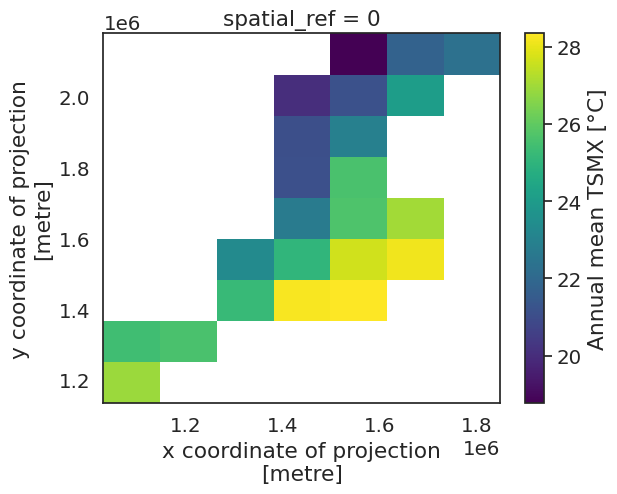

In [28]:
masked_files_list[1]["annual_mean"].plot() #Temperature 

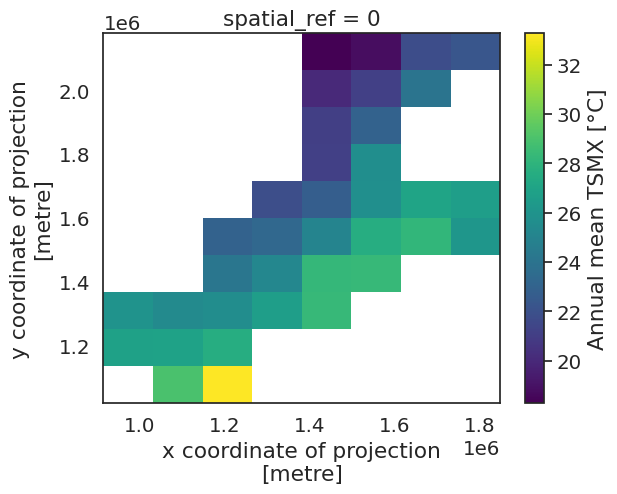

In [10]:
ma_p[0]["annual_mean"].plot() #Temperature 

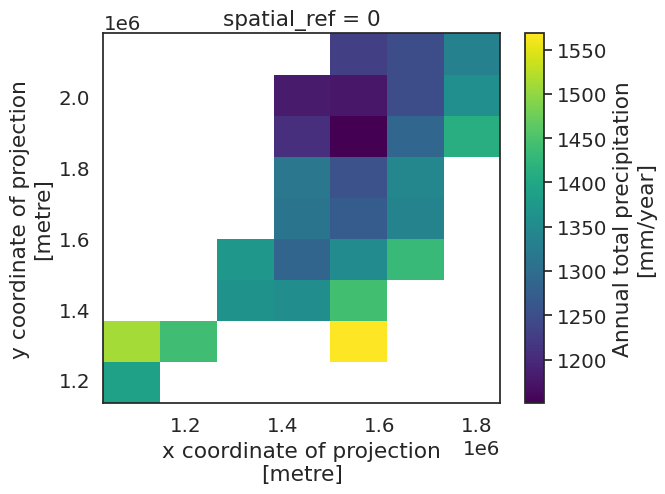

In [27]:
masked_files_list[0]["PRCPTOT"].plot() #Precipitation

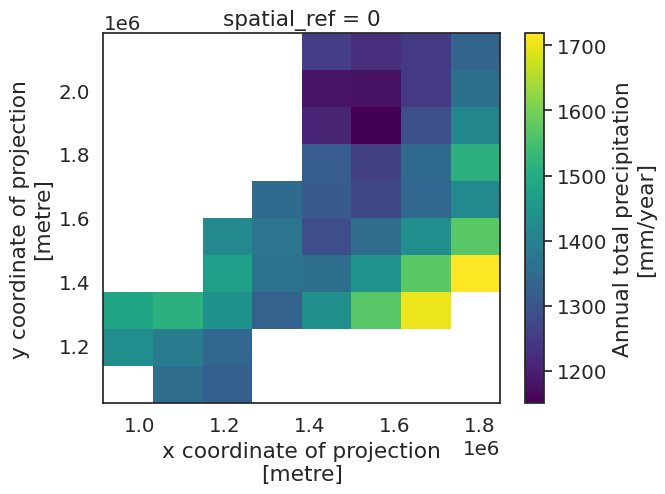

In [9]:
ma_p[1]["PRCPTOT"].plot() #Precipitation 

## get_present_yearly_all_data_dataframe ReadMe
Takes all .nc files in `L1/present/sliced_and_avged` and `L1/future/sliced_and_avged` (global climate data), and for one specified location, gets the average of each climate variable for every single year in timeframe (depends on whether you input present or future). Saves as a .csv file, where rows are specified by a specific year.   
! Important! I uhhhh I didn't do this for buffered points or regions...   
Parameter explanation:  
* `time_frame`: `String` of either present or future. 
* `input_path`: `String` of the path from where you can access the sliced and averaged files.
* `location_name`: `String` of what the point refers to. 
* `projection`: `String` of the CRS you want to reproject your data into. Should be in format like `"EPSG:5070"`. 
* `* target_lat`: `float`. Latitude of the point you want to get the data from.
* `* target_lon`: `float`. Longitude of the point you want to get the data from. Range from -180 to 180.


In [9]:
#CHANGED THE COORDINATES CALCULATIONS

def convert_longitude(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    ds = ds.sortby('lon')
    return ds

def get_present_yearly_all_data_dataframe(time_frame, input_path, location_name, projection, output_path, *, target_lat = None, target_lon = None):
    climate_scenario = ["ARISE_SAI_1p0", "ARISE_SAI_1p5", "SSP245"]
    climate_variables = ["SSP", "TSMX", "PRECT"]

    if (time_frame == "present"):
        start_year = 2015
        end_year = 2035
    if (time_frame == "future"):
        start_year = 2050
        end_year = 2070
    
    info_list = {}

    list_of_files = glob.glob(input_path + '/*.nc') 
    file_reprojected = []
    
    for each in list_of_files:
        file = xr.open_dataset(each)
        file_reprojected.append(file)

    output_list = []
    
    for each in file_reprojected:
        data_vars = list(each.data_vars)
        yearly_list = []
        for year in range(start_year, end_year):
            output_data = {
            "location": location_name, 
            "projection": projection, 
            "scenario" : each.attrs["scenario"]
            }
            
            sliced = each.sel(year = slice(year, year)).copy()
            #sliced = sliced.squeeze(dim = "year")
            sliced = sliced.sel(lat=target_lat, lon=target_lon, method='nearest')
            
            sliced.attrs["title_description"] = sliced.attrs["scenario"] + " " + sliced.attrs["variable"] + " " + str(year)


            # point_data = sliced.rio.clip(gdf_projected.geometry, drop = True, all_touched=True)
    
            output_data["year"] = str(year)
            for var in data_vars: 
                output_data[sliced.variable + "_" + var + "_avg"] = np.nanmean(sliced[var].values)
        
            output_list.append(output_data)
        
    
    output_df = pd.DataFrame(output_list)
    merged_output_df = output_df.groupby(["location", "projection", "year", "scenario"], as_index=False).first()  
        
    merged_output_df.to_csv(output_path, index=False)


### Example of getting yearly data
First cell crops and saves the data in the present for 2 locations, Philly and East Lansing.   
Second cell crops and saves the data for the future for 2 locations, Philly and East Lansing. This has 3 scenarios (for the 3 climate scenarios) as opposed to the 1 scenario in the first cell. This is why there more rows. 

In [11]:
#Present yearly data for east lansing/philly
get_present_yearly_all_data_dataframe("present", "/mnt/research/nasabio/data/climate/L1/present/sliced_and_avged", "East Lansing", "EPSG:5070", "/mnt/research/nasabio/data/climate/L1/analog_calculations/present/yearly/yearly_temporal_avg_East_Lansing.csv", target_lat = 42.7370, target_lon = -84.4839) #East lansing

get_present_yearly_all_data_dataframe("present", "/mnt/research/nasabio/data/climate/L1/present/sliced_and_avged", "Philadelphia", "EPSG:5070", "/mnt/research/nasabio/data/climate/L1/analog_calculations/present/yearly/yearly_temporal_avg_Philadelphia.csv", target_lat = 39.952583, target_lon = -75.165222) #Philly

/tmp/ipykernel_1164416/2578586359.py:51: RuntimeWarning: Mean of empty slice
  output_data[sliced.variable + "_" + var + "_avg"] = np.nanmean(sliced[var].values)
/tmp/ipykernel_1164416/2578586359.py:51: RuntimeWarning: Mean of empty slice
  output_data[sliced.variable + "_" + var + "_avg"] = np.nanmean(sliced[var].values)


In [13]:
#Future yearly data for east lansing/philly
get_present_yearly_all_data_dataframe("future", "/mnt/research/nasabio/data/climate/L1/future/sliced_and_avged", "East Lansing", "EPSG:5070", "/mnt/research/nasabio/data/climate/L1/analog_calculations/future/yearly/yearly_temporal_avg_East_Lansing.csv", target_lat = 42.7370, target_lon = -84.4839) #East lansing

get_present_yearly_all_data_dataframe("future", "/mnt/research/nasabio/data/climate/L1/future/sliced_and_avged", "Philadelphia", "EPSG:5070", "/mnt/research/nasabio/data/climate/L1/analog_calculations/future/yearly/yearly_temporal_avg_Philadelphia.csv", target_lat = 39.952583, target_lon = -75.165222) #Philly


# TESTING BELOW, IGNORE!

16.656378


NameError: name 'ex_data1' is not defined

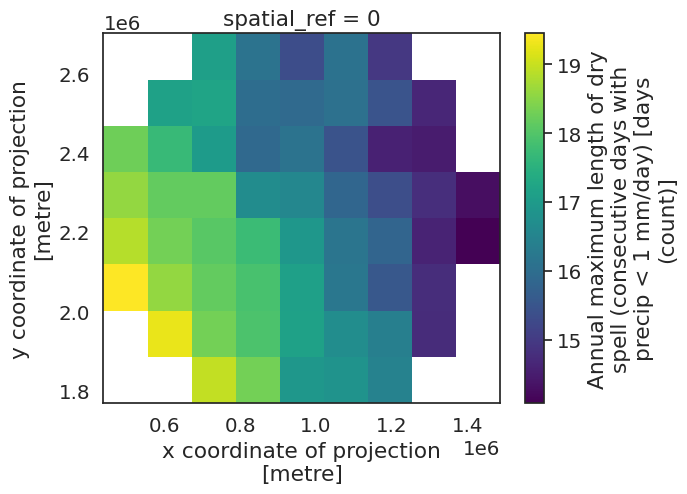

In [24]:
path_file = "/mnt/research/nasabio/data/climate/L1/SSP245/ensemble_avg/EXAMPLE_SSP245_avg_PRECT_values_2015-2034.nc"
ex_data = xr.open_dataset(path_file)
#ex_data = ex_data1["CDD"]

location_type = ["point", "polygon"]        #A choice of getting a point or a region. 
buffer = range(10)                 #A choice of a buffering area around the point or region. 

target_lat = 42.7370
target_lon = -84.4839     #275.5161 Need to make method to convert!!!!
#East Lansing example

target_time_start = 2015
target_time_end = 2034 
#using these values because I already have a file for the averages over this time period for precipitation. 
#But for something else, you would need to first get the data first. I will modify my method so that it wont actually save a file?





point = Point(target_lon, target_lat)

gdf_point = gpd.GeoDataFrame(geometry=[point], crs="EPSG:4326")
gdf_projected = gdf_point.to_crs("EPSG:5070") #CONUS coordinate. Can change later, but biodiversity data is in CONUS
buffered_geom = gdf_projected.geometry.buffer(500000) #500km buffer. 
#buffered_geom.plot() #Circle shape


# #reprojecting ex_data to EPSG 5070. 
ex_data = ex_data.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
ex_data.rio.write_crs("EPSG:4326", inplace=True) #Set our reference system (mercator projection)
ex_data_reprojected = ex_data.rio.reproject("EPSG:5070")


masked_data = ex_data_reprojected.rio.clip(buffered_geom.geometry, drop = True)

print(np.nanmean(masked_data["CDD"].values))

masked_data["CDD"].plot()

print(type(ex_data1.data_vars))

#project the raster (netcdf file) into crs 
#reproject raster to 5070
#and then spatial intersection. to see which pixels overlap 

#print(ex_data_reprojected["lon"])

buffered_mask = regionmask.mask_geopandas(buffered_geom, ex_data_reprojected.x, ex_data_reprojected.y)
slice_mask = ex_data_reprojected["CDD"].where(buffered_mask)
slice_mask.plot()


buffered_geom_latlon = buffered_geom.to_crs("EPSG:4326") 


point_data = ex_data.sel(lat=target_lat, lon=-target_lon, method='nearest')


<xarray.Dataset> Size: 1kB
Dimensions:  (lat: 8, lon: 9)
Coordinates:
  * lat      (lat) float64 64B 33.46 34.4 35.34 36.28 37.23 38.17 39.11 40.05
  * lon      (lon) float64 72B 275.0 276.2 277.5 278.8 ... 282.5 283.8 285.0
Data variables:
    CDD      (lat, lon) float32 288B 16.8 17.31 nan 16.44 ... 15.57 15.55 14.89
    CWD      (lat, lon) float32 288B 15.86 15.81 nan 15.11 ... 8.905 8.515 8.505
    PRCPTOT  (lat, lon) float32 288B 1.496e+03 1.457e+03 ... 1.272e+03 1.358e+03
    R95pTOT  (lat, lon) float32 288B 366.5 362.6 nan 350.5 ... 285.2 298.1 315.0
Attributes:
    scenario:                  ARISE_SAI_1p5
    member:                    007
    variable:                  PRECT
    clim_reference:            SSP245 2015-2034
    wet_day_threshold_mm_day:  1.0
    source_unit_conversion:    PRECT [m/s] x 86400 x 1000 -> mm/day

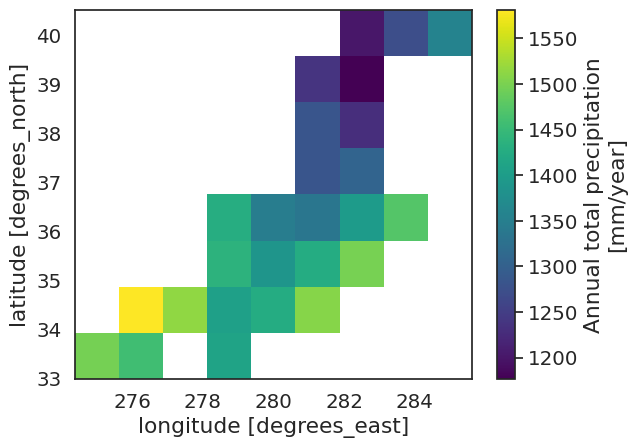

In [52]:
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"

NEON_sites = gpd.read_file(mask_path)
NEON_sites.head()
mid_atl = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]


path_file = "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p5/ensemble_avg/EXAMPLE_ARISE_SAI_1p5_avg_PRECT_values_2050-2069.nc"
ex_data = xr.open_dataset(path_file)


mid_atl_mask = regionmask.mask_geopandas(mid_atl, ex_data.lon, ex_data.lat)


sliced_masked = ex_data.where(mid_atl_mask == 1, drop=True)
#So this sidesteps the need to manually crop because drop = True. We are only keeping the pixels where there is something(1)
#rather than nothing, (0)

sliced_masked["PRCPTOT"].plot()

sliced_masked

In [2]:
#expect shapefile in 5070. Time should be future or past.
#For simplicity, we are going to assume that the future and past data is stured in L1 folder, named 
#avg_past and avg_future. And that in this, it is the average of the data, globally
#and it is named in this format: climate_scenario + "_" + climate_variable + ".nc"

#BUFFER NEEDS TO BE AT LEAST 100KM OR 100,000 METERS! OR ELSE ERROR, OR ELSE JUST DONT PUT A BUFFER AT ALL! Recommend 300km or more. 
def get_location_data(input_path, *, target_lat = None, target_lon = None, shapefile = None, buffer = None):
    climate_scenario = ["ARISE_SAI_1p0", "ARISE_SAI_1p5", "SSP245"]
    climate_variables = ["SSP", "TSMX", "PRECT"]
    
    info_list = {}
    
    if (target_lat != None and target_lon != None and shapefile == None):
        point_latlon = Point(target_lon, target_lat)
        masked_files_list = []
        
        if (buffer != None): 
            list_of_files = glob.glob(input_path + '/*.nc') 
            for each in list_of_files:
                file = xr.open_dataset(each)
                file = file.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
                file.rio.write_crs("EPSG:4326", inplace=True) #Set our reference system (mercator projection)
                file_reprojected = file.rio.reproject("EPSG:5070")
                
                point = Point(target_lon, target_lat)
                gdf_point = gpd.GeoDataFrame(geometry=[point], crs="EPSG:4326")
                gdf_projected = gdf_point.to_crs("EPSG:5070") #CONUS coordinate.
                buffered_geom = gdf_projected.geometry.buffer(buffer) #apply buffer.
                
                masked_data = file_reprojected.rio.clip(buffered_geom.geometry, drop = True) #Set true if you want to crop it. 
                
                masked_files_list.append(masked_data)
            return masked_files_list
            
        else: 
            list_of_files = glob.glob(input_path + '/*.nc') 
            for each in list_of_files:
                file = xr.open_dataset(each)
                buffered_point_data = file.sel(lat=target_lat, lon=-target_lon, method='nearest')
                masked_files_list.append(buffered_point_data)
            return masked_files_list
                    
    elif (target_lat == None and target_lon == None):          
        masked_files_list = []
        
        list_of_files = glob.glob(input_path + '/*.nc') 
        for each in list_of_files:
            file = xr.open_dataset(each)
            mask = regionmask.mask_geopandas(shapefile, file.lon, file.lat)
            sliced_masked = file.where(mask.notnull(), drop=True)
            masked_files_list.append(sliced_masked)
        return masked_files_list
    else: 
        return("Please enter either a point or a shapefile correctly.")
    #Checking for correct inputs. 

    

x = get_location_data("/mnt/research/nasabio/data/climate/L1/present", buffer = 500000, target_lat = 42.7370, target_lon = -84.4839) #East lansing

p = get_location_data("/mnt/research/nasabio/data/climate/L1/present", buffer = 300000, target_lat = 39.952583, target_lon = -75.165222) #Philly

beijing = get_location_data("/mnt/research/nasabio/data/climate/L1/future", target_lat = 39.9045, target_lon = 116.3910)


mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
mid_atl = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]
y = get_location_data("/mnt/research/nasabio/data/climate/L1/present", shapefile = mid_atl)

great_lakes = NEON_sites[NEON_sites.domainName == "Great Lakes"]
z = get_location_data("/mnt/research/nasabio/data/climate/L1/present", shapefile = great_lakes)

south_plains = NEON_sites[NEON_sites.domainName == "Southern Plains"]
sp = get_location_data("/mnt/research/nasabio/data/climate/L1/future", shapefile = south_plains)



In [ ]:
#list_of_files = glob.glob(path + '/**/*.nc', recursive=True) 